# Validation and Difficulty Scoring

When creating simulated data for benchmarking, two critical questions arise:

1. **How realistic is the simulation?** (Validation)
2. **How difficult is the classification task?** (Difficulty Scoring)

PointillSim provides tools to answer both questions quantitatively.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

np.random.seed(42)

from pointillsim import (
    TissueCellTypes,
    CellTypesProperties,
    HybISS_Setup,
    FOVDistribution,
    FrameWideElement,
    VacuolatedStructure,
    RandomCellTypeRule,
    MixOfNCellTypesRule,
    DistanceBasedRule,
    CompositeRule,
    LayerRule,
    GradientRule,
    DeterministicNeighborAssignment,
)

# Import validation module
from pointillsim.validation import (
    DifficultyScorer,
    ValidationMetrics,
)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.facecolor'] = 'white'
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
# Create sample tissues with different characteristics
n_cell_types = 5
n_genes = 50
frame_size = 600

# Easy tissue: Clear markers, high concentration
tissue_easy = TissueCellTypes()
tissue_easy.generate_types_and_markers(
    n_genes=n_genes,
    n_cell_types=n_cell_types,
    expected_level=20.0,      # High expression
    concentration=0.95,        # Very distinct markers
)

# Hard tissue: Overlapping markers, low concentration, MORE cell types
n_cell_types_hard = 8  # More cell types = more confusion
tissue_hard = TissueCellTypes()
tissue_hard.generate_types_and_markers(
    n_genes=n_genes,
    n_cell_types=n_cell_types_hard,
    expected_level=3.0,        # Very low expression
    concentration=0.35,        # Highly overlapping markers
)

cell_props = CellTypesProperties(n_cell_types=n_cell_types)
cell_props_hard = CellTypesProperties(n_cell_types=n_cell_types_hard)

print("Created two tissue profiles:")
print(f"  Easy: {n_cell_types} types, concentration={0.95}, expression level={20.0}")
print(f"  Hard: {n_cell_types_hard} types, concentration={0.35}, expression level={3.0}")

Created two tissue profiles:
  Easy: 5 types, concentration=0.95, expression level=20.0
  Hard: 8 types, concentration=0.35, expression level=3.0


---
## 1. Difficulty Scoring

The `DifficultyScorer` quantifies how challenging a cell type classification task is. It uses:

- **Separability metrics**: How distinct are the cell type expression profiles?
- **Spatial complexity**: How mixed are cell types spatially?
- **Optional classifier accuracy**: Actual classification performance estimate

### Creating Truly Challenging Simulations

To create a **truly difficult** classification task, we combine multiple strategies:

1. **Overlapping expression profiles**: Low concentration parameter (0.35) and low expression (3.0)
2. **More cell types**: 8 types instead of 5 increases confusion
3. **Simple spatial patterns**: Random cell type assignment

**Important Note:** Spatial patterns affect difficulty in counter-intuitive ways:
- **Simple random patterns** → HARDER classification (no spatial structure to learn)
- **Complex structured patterns** (gradients, layers) → EASIER classification (spatial structure helps)

See Cell 21 for detailed demonstration of this phenomenon!

In [3]:
# Create difficulty scorers
scorer_easy = DifficultyScorer()
scorer_hard = DifficultyScorer()

print(f"DifficultyScorer initialized for {n_cell_types} and {n_cell_types_hard} cell types")

DifficultyScorer initialized for 5 and 8 cell types


In [4]:
# Generate FOVs with different spatial complexity

# Easy FOV: Simple, organized spatial patterns
def generate_fov_easy(tissue, n_types):
    fov_dist = FOVDistribution(
        frame_size=frame_size,
        background_element=lambda: FrameWideElement(
            frame_size=frame_size,
            tipical_cell_spacing=15,
            rules=RandomCellTypeRule(n_cell_types=n_types)
        ),
        other_elements=[
            lambda: VacuolatedStructure(
                frame_size=frame_size,
                scale=80,
                hole_scale_factor=0.4,
                tipical_cell_spacing=10,
                rules=DistanceBasedRule(
                    n_cell_types=n_types,
                    inner_type=2,
                    outer_type=3,
                )
            )
        ],
        elements_frequency=[1.0],
        attempts_at_elements=3,
    )
    
    fov = fov_dist.generate_fov()
    return fov

# Hard FOV: Highly mixed spatial patterns with composite rules
def generate_fov_hard(tissue, n_types):
    """Create highly complex spatial patterns that are difficult to classify."""
    fov_dist = FOVDistribution(
        frame_size=frame_size,
        background_element=lambda: FrameWideElement(
            frame_size=frame_size,
            tipical_cell_spacing=12,
            # Mix of all cell types randomly distributed
            rules=MixOfNCellTypesRule(n_cell_types=n_types, list_N=list(range(n_types)))
        ),
        other_elements=[
            # Element 1: Vacuolated structure with gradient (creates smooth transitions)
            lambda: VacuolatedStructure(
                frame_size=frame_size,
                scale=100,
                hole_scale_factor=0.5,
                tipical_cell_spacing=10,
                rules=CompositeRule(
                    rules=[
                        GradientRule(
                            n_cell_types=n_types,
                            start_type=0,
                            end_type=n_types-1,
                            direction="horizontal",
                            transition_width=0.8,  # Very wide transition
                            sharpness=0.5,  # Soft transition
                        ),
                        MixOfNCellTypesRule(
                            n_cell_types=n_types, 
                            list_N=list(range(min(4, n_types)))
                        )
                    ],
                    weights=[0.5, 0.5],  # Equal mixing
                    mode="average"
                )
            ),
            # Element 2: Another structure with layering
            lambda: VacuolatedStructure(
                frame_size=frame_size,
                scale=90,
                hole_scale_factor=0.3,
                tipical_cell_spacing=11,
                rules=LayerRule(
                    n_cell_types=n_types,
                    layer_types=[i for i in range(min(4, n_types))],  # Multiple layers
                    transition_width=25.0,  # Wide, fuzzy boundaries
                    sharpness=0.5,  # Soft transitions
                )
            ),
        ],
        elements_frequency=[1.2, 0.8],  # Overlapping elements
        attempts_at_elements=4,
    )
    
    fov = fov_dist.generate_fov()
    return fov

np.random.seed(42)
fov_easy = generate_fov_easy(tissue_easy, n_cell_types)
cell_props.apply(fov_easy)
hybiss_easy = HybISS_Setup(tissue_easy)
hybiss_easy.observe_dots(fov_easy)

np.random.seed(42)
fov_hard = generate_fov_hard(tissue_hard, n_cell_types_hard)
cell_props_hard.apply(fov_hard)
hybiss_hard = HybISS_Setup(tissue_hard)
hybiss_hard.observe_dots(fov_hard)

print(f"Generated FOVs:")
print(f"  Easy: {fov_easy.n_cells} cells, {n_cell_types} types")
print(f"  Hard: {fov_hard.n_cells} cells, {n_cell_types_hard} types")

Generated FOVs:
  Easy: 1835 cells, 5 types
  Hard: 2831 cells, 8 types


In [5]:
# Helper function to convert dots to count matrix
def get_count_matrix(fov, hybiss, tissue):
    """Convert dots to cell × gene count matrix."""
    n_cells = fov.n_cells
    n_genes = tissue.n_genes
    
    # Initialize count matrix
    counts = np.zeros((n_cells, n_genes))
    
    # Get dots dataframe
    dots_df = hybiss.make_pandas_df()
    
    # Gene name to index mapping
    gene_to_idx = {g: i for i, g in enumerate(tissue.gene_names)}
    
    # Count transcripts per cell per gene
    for _, row in dots_df.iterrows():
        cell_idx = int(row['cell'])
        gene_idx = gene_to_idx.get(row['gene'], -1)
        if 0 <= cell_idx < n_cells and gene_idx >= 0:
            counts[cell_idx, gene_idx] += 1
    
    return counts

# Generate count matrices (required for DifficultyScorer and ValidationMetrics)
counts_easy = get_count_matrix(fov_easy, hybiss_easy, tissue_easy)
counts_hard = get_count_matrix(fov_hard, hybiss_hard, tissue_hard)

print(f"Count matrices:")
print(f"  Easy: {counts_easy.shape} (cells × genes), {counts_easy.sum():.0f} total counts")
print(f"  Hard: {counts_hard.shape} (cells × genes), {counts_hard.sum():.0f} total counts")

Count matrices:
  Easy: (1835, 50) (cells × genes), 36405 total counts
  Hard: (2831, 50) (cells × genes), 10550 total counts


In [6]:
# Score both tissues using count matrices
score_easy = scorer_easy.score(
    counts_easy, 
    fov_easy.class_instance,
    positions=fov_easy.cell_centroids
)
score_hard = scorer_hard.score(
    counts_hard,
    fov_hard.class_instance,
    positions=fov_hard.cell_centroids
)

print("Difficulty Scores:")
print(f"\n  Easy tissue:")
for metric, value in score_easy.items():
    print(f"    {metric}: {value:.3f}")

print(f"\n  Hard tissue:")
for metric, value in score_hard.items():
    print(f"    {metric}: {value:.3f}")

Difficulty Scores:

  Easy tissue:
    class_imbalance: 0.158
    separability: 0.562
    classifier_accuracy: 1.000
    spatial_complexity: 0.998
    overall: 0.363

  Hard tissue:
    class_imbalance: 0.979
    separability: 0.166
    classifier_accuracy: 0.695
    spatial_complexity: 0.879
    overall: 0.713


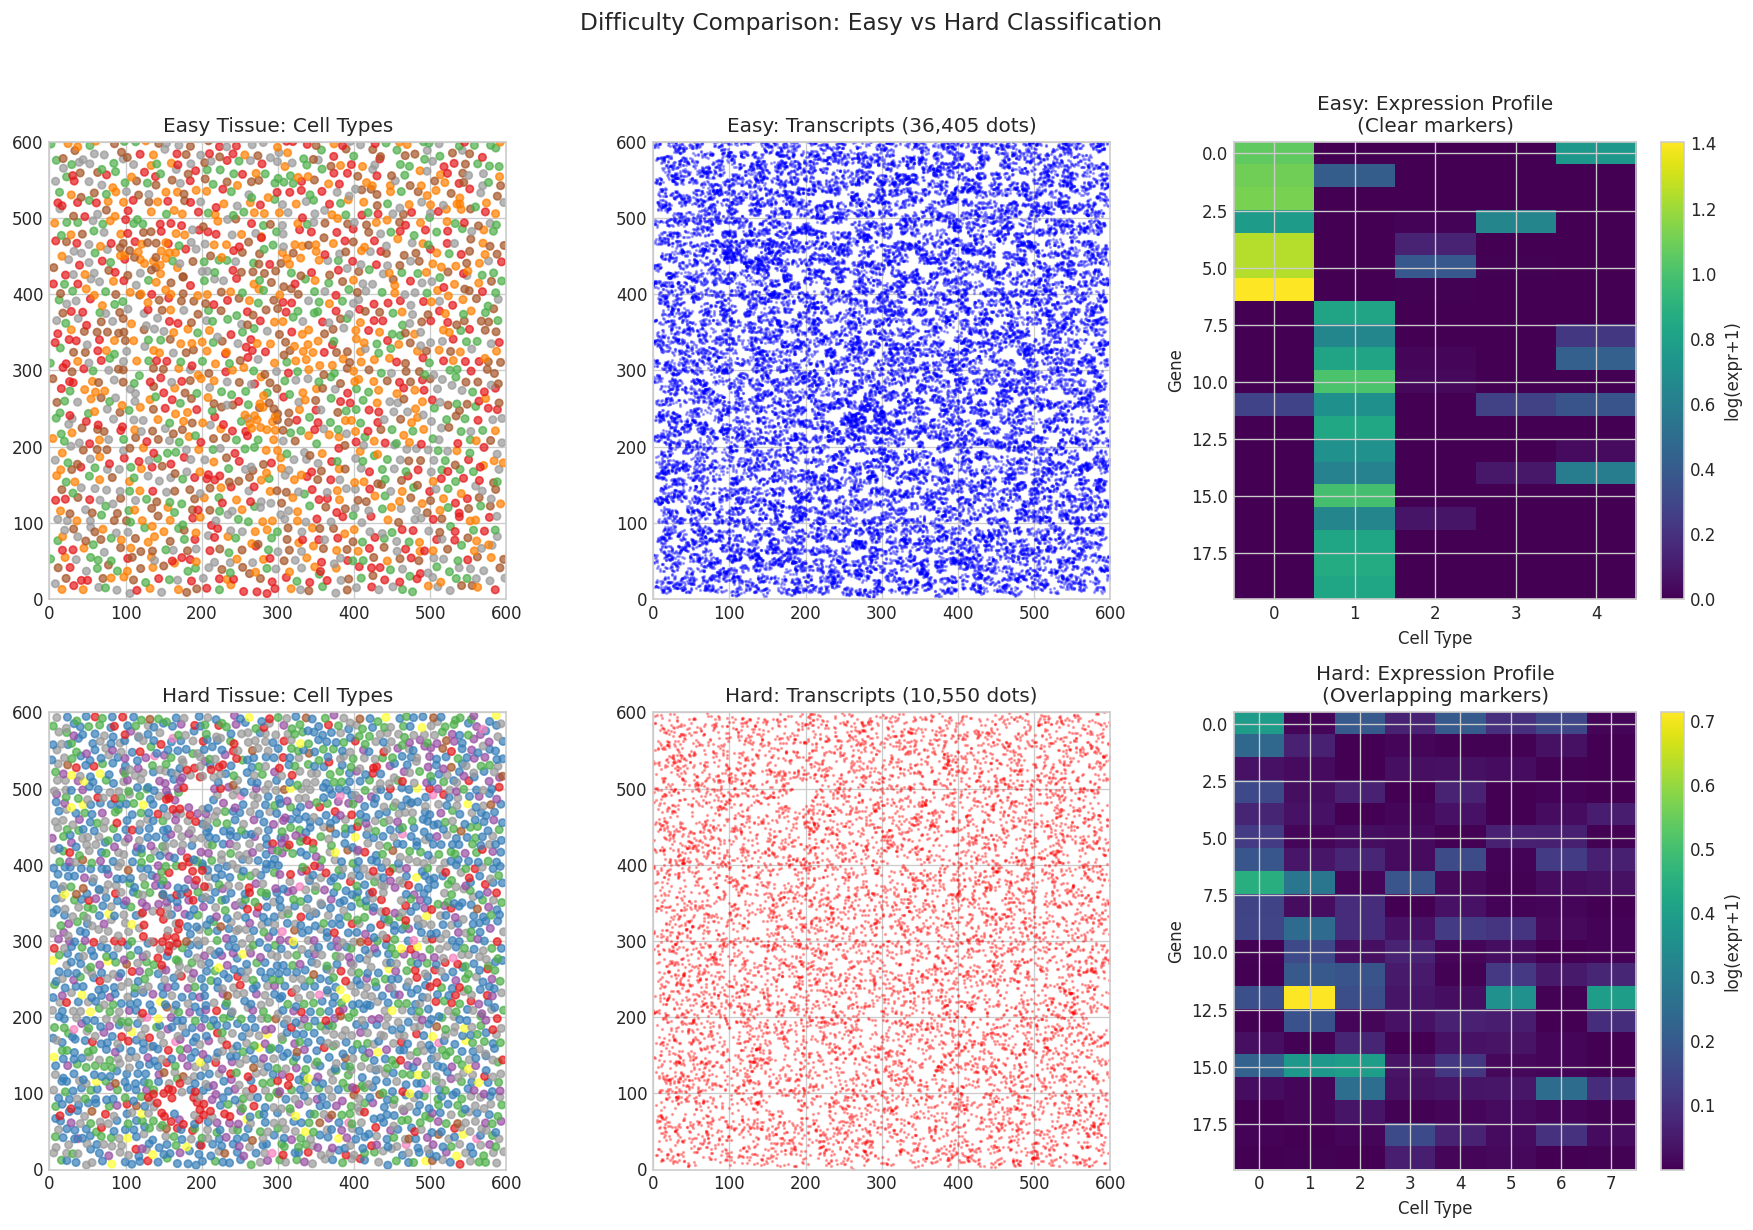

In [7]:
# Get dots dataframes for visualization
dots_easy = hybiss_easy.make_pandas_df()
dots_hard = hybiss_hard.make_pandas_df()

# Visualize the difficulty difference
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Row 1: Easy tissue
ax = axes[0, 0]
ax.scatter(fov_easy.cell_centroids[:, 0], fov_easy.cell_centroids[:, 1],
           c=fov_easy.class_instance, cmap='Set1', s=20, alpha=0.7)
ax.set_xlim(0, frame_size)
ax.set_ylim(0, frame_size)
ax.set_aspect('equal')
ax.set_title('Easy Tissue: Cell Types')

ax = axes[0, 1]
ax.scatter(dots_easy['x'], dots_easy['y'], s=1, alpha=0.3, c='blue')
ax.set_xlim(0, frame_size)
ax.set_ylim(0, frame_size)
ax.set_aspect('equal')
ax.set_title(f'Easy: Transcripts ({len(dots_easy):,} dots)')

ax = axes[0, 2]
im = ax.imshow(np.log1p(tissue_easy.gene_expression_by_type[:20, :]), 
               aspect='auto', cmap='viridis')
ax.set_xlabel('Cell Type')
ax.set_ylabel('Gene')
ax.set_title('Easy: Expression Profile\n(Clear markers)')
plt.colorbar(im, ax=ax, label='log(expr+1)')

# Row 2: Hard tissue
ax = axes[1, 0]
ax.scatter(fov_hard.cell_centroids[:, 0], fov_hard.cell_centroids[:, 1],
           c=fov_hard.class_instance, cmap='Set1', s=20, alpha=0.7)
ax.set_xlim(0, frame_size)
ax.set_ylim(0, frame_size)
ax.set_aspect('equal')
ax.set_title('Hard Tissue: Cell Types')

ax = axes[1, 1]
ax.scatter(dots_hard['x'], dots_hard['y'], s=1, alpha=0.3, c='red')
ax.set_xlim(0, frame_size)
ax.set_ylim(0, frame_size)
ax.set_aspect('equal')
ax.set_title(f'Hard: Transcripts ({len(dots_hard):,} dots)')

ax = axes[1, 2]
im = ax.imshow(np.log1p(tissue_hard.gene_expression_by_type[:20, :]), 
               aspect='auto', cmap='viridis')
ax.set_xlabel('Cell Type')
ax.set_ylabel('Gene')
ax.set_title('Hard: Expression Profile\n(Overlapping markers)')
plt.colorbar(im, ax=ax, label='log(expr+1)')

plt.suptitle('Difficulty Comparison: Easy vs Hard Classification', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

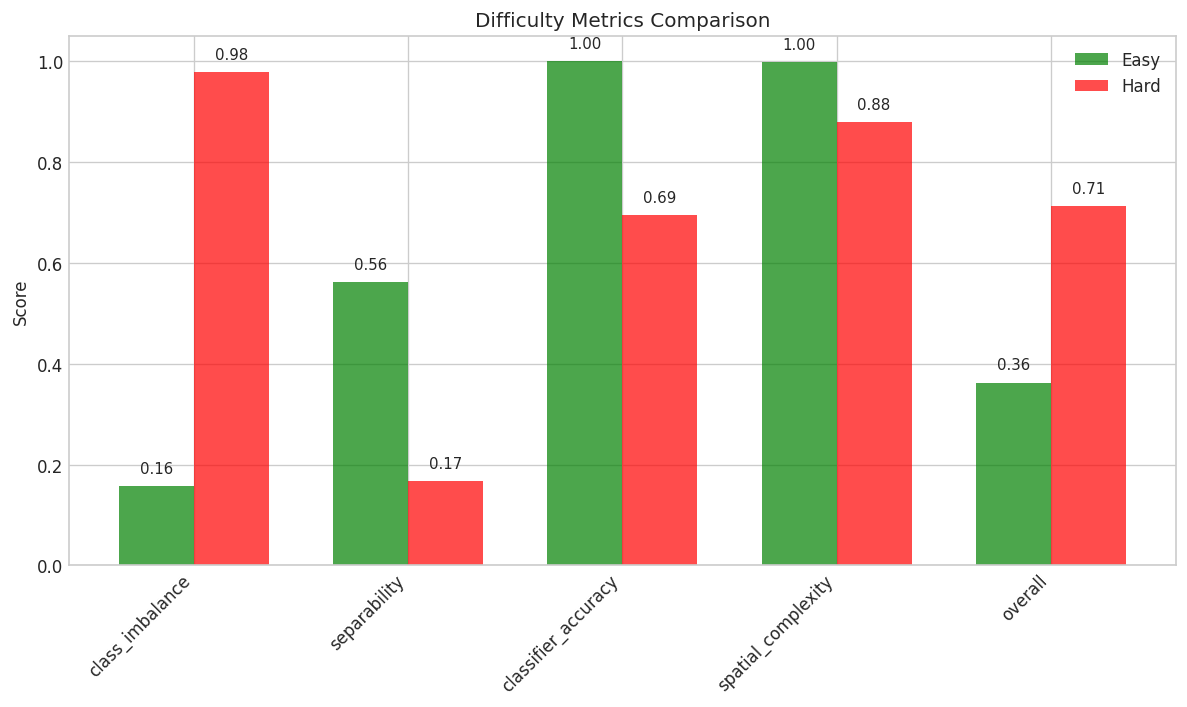


Interpretation:
  - Higher separability = easier classification (better separated cell types)
  - Higher spatial_mixing = more intermixed tissue (harder to classify)
  - Higher overall_difficulty = harder task


In [8]:
# Compare scores visually
fig, ax = plt.subplots(figsize=(10, 6))

metrics = list(score_easy.keys())
easy_values = [score_easy[m] for m in metrics]
hard_values = [score_hard[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

bars1 = ax.bar(x - width/2, easy_values, width, label='Easy', color='green', alpha=0.7)
bars2 = ax.bar(x + width/2, hard_values, width, label='Hard', color='red', alpha=0.7)

ax.set_ylabel('Score')
ax.set_title('Difficulty Metrics Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics, rotation=45, ha='right')
ax.legend()

# Add value labels
for bar, val in zip(bars1, easy_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2f}', ha='center', va='bottom', fontsize=9)
for bar, val in zip(bars2, hard_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("  - Higher separability = easier classification (better separated cell types)")
print("  - Higher spatial_mixing = more intermixed tissue (harder to classify)")
print("  - Higher overall_difficulty = harder task")

---
## 2. Classifier-Based Difficulty Estimation

For a more practical difficulty measure, we can train a classifier and measure its accuracy.

In [9]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

def estimate_classifier_accuracy(counts, labels, classifier='logistic'):
    """Estimate classification accuracy using cross-validation."""
    # Normalize counts
    scaler = StandardScaler()
    X = scaler.fit_transform(np.log1p(counts))
    y = labels
    
    if classifier == 'logistic':
        clf = LogisticRegression(max_iter=1000, random_state=42)
    else:
        clf = RandomForestClassifier(n_estimators=100, random_state=42)
    
    scores = cross_val_score(clf, X, y, cv=5, scoring='accuracy')
    
    return scores.mean(), scores.std()

# Classify easy tissue
acc_easy_lr, std_easy_lr = estimate_classifier_accuracy(
    counts_easy, fov_easy.class_instance, 'logistic'
)
acc_easy_rf, std_easy_rf = estimate_classifier_accuracy(
    counts_easy, fov_easy.class_instance, 'rf'
)

# Classify hard tissue
acc_hard_lr, std_hard_lr = estimate_classifier_accuracy(
    counts_hard, fov_hard.class_instance, 'logistic'
)
acc_hard_rf, std_hard_rf = estimate_classifier_accuracy(
    counts_hard, fov_hard.class_instance, 'rf'
)

print("Classification Accuracy (5-fold CV):")
print(f"\n  Easy Tissue:")
print(f"    Logistic Regression: {acc_easy_lr:.1%} ± {std_easy_lr:.1%}")
print(f"    Random Forest:       {acc_easy_rf:.1%} ± {std_easy_rf:.1%}")
print(f"\n  Hard Tissue:")
print(f"    Logistic Regression: {acc_hard_lr:.1%} ± {std_hard_lr:.1%}")
print(f"    Random Forest:       {acc_hard_rf:.1%} ± {std_hard_rf:.1%}")

Classification Accuracy (5-fold CV):

  Easy Tissue:
    Logistic Regression: 100.0% ± 0.0%
    Random Forest:       100.0% ± 0.0%

  Hard Tissue:
    Logistic Regression: 75.0% ± 1.3%
    Random Forest:       70.0% ± 1.2%


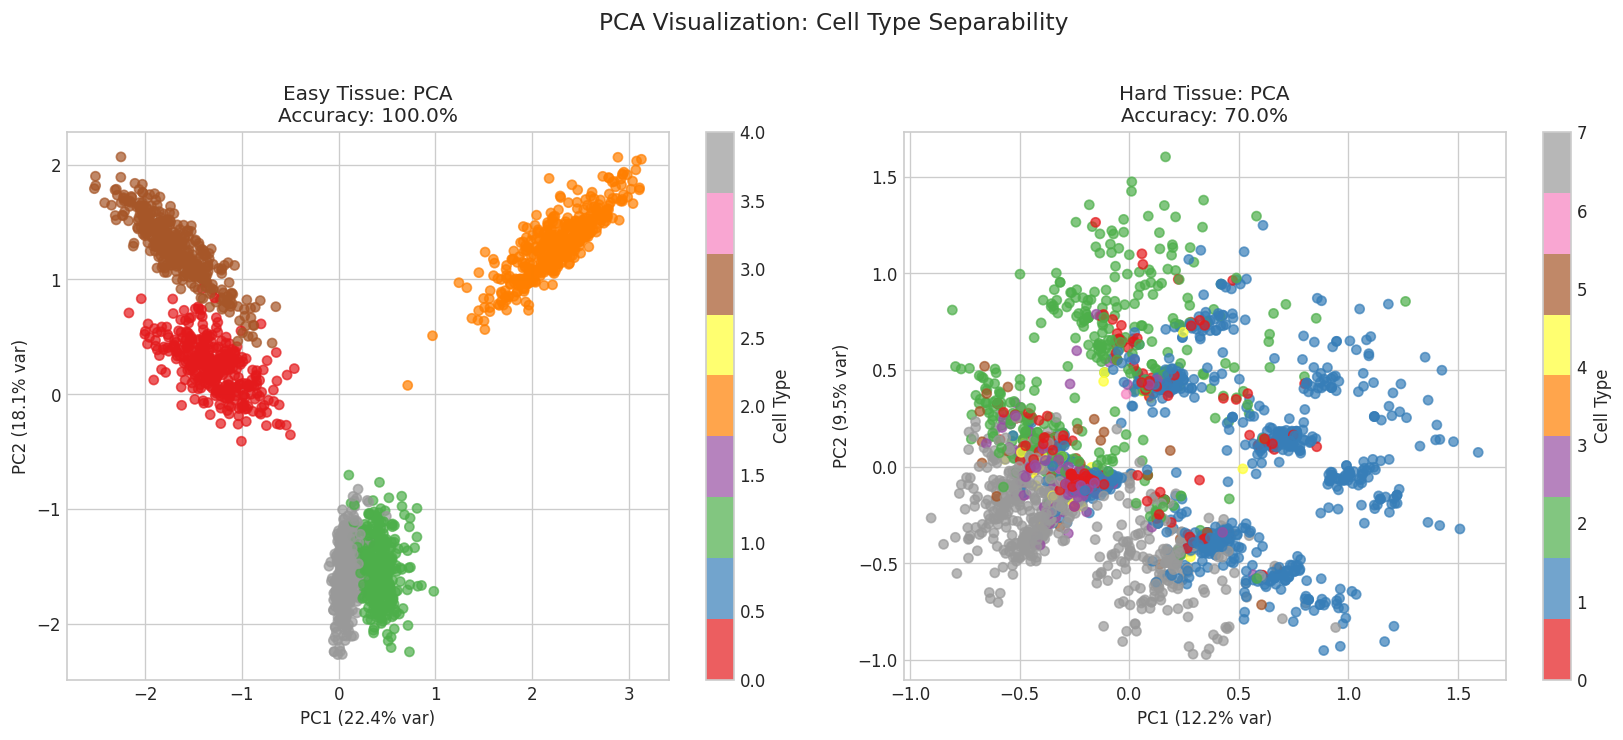

In [10]:
# Visualize in reduced dimensions
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PCA on easy tissue
pca = PCA(n_components=2)
X_easy_pca = pca.fit_transform(np.log1p(counts_easy))

ax = axes[0]
scatter = ax.scatter(X_easy_pca[:, 0], X_easy_pca[:, 1],
                     c=fov_easy.class_instance, cmap='Set1',
                     s=30, alpha=0.7)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
ax.set_title(f'Easy Tissue: PCA\nAccuracy: {acc_easy_rf:.1%}')
plt.colorbar(scatter, ax=ax, label='Cell Type')

# PCA on hard tissue
X_hard_pca = pca.fit_transform(np.log1p(counts_hard))

ax = axes[1]
scatter = ax.scatter(X_hard_pca[:, 0], X_hard_pca[:, 1],
                     c=fov_hard.class_instance, cmap='Set1',
                     s=30, alpha=0.7)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
ax.set_title(f'Hard Tissue: PCA\nAccuracy: {acc_hard_rf:.1%}')
plt.colorbar(scatter, ax=ax, label='Cell Type')

plt.suptitle('PCA Visualization: Cell Type Separability', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [13]:
# Create a "reference" dataset (simulated with specific parameters)
np.random.seed(123)

# Reference tissue
tissue_ref = TissueCellTypes()
tissue_ref.generate_types_and_markers(
    n_genes=n_genes,
    n_cell_types=n_cell_types,
    expected_level=12.0,
    concentration=0.8,
)

# Generate reference FOV using easy generation function
fov_ref = generate_fov_easy(tissue_ref, n_cell_types)
cell_props_ref = CellTypesProperties(n_cell_types=n_cell_types)
cell_props_ref.apply(fov_ref)
hybiss_ref = HybISS_Setup(tissue_ref)
hybiss_ref.observe_dots(fov_ref)
counts_ref = get_count_matrix(fov_ref, hybiss_ref, tissue_ref)

print(f"Reference dataset: {fov_ref.n_cells} cells, {counts_ref.sum():.0f} total counts")

Reference dataset: 1853 cells, 23244 total counts


In [14]:
# Create ValidationMetrics
validator = ValidationMetrics()

# Compare easy tissue to reference (both have 5 types)
metrics_easy = validator.compare(
    simulated_expression=counts_easy,
    real_expression=counts_ref,
    simulated_types=fov_easy.class_instance,
    real_types=fov_ref.class_instance,
)

# Note: Hard tissue has 8 types vs reference's 5 types
# Validation metrics will still compute, but type proportion similarity may be affected
metrics_hard = validator.compare(
    simulated_expression=counts_hard,
    real_expression=counts_ref,
    simulated_types=fov_hard.class_instance,
    real_types=fov_ref.class_instance,
)

print("Validation Metrics (vs Reference):")
print(f"\n  Easy Tissue (5 types vs 5 types):")
for metric, value in metrics_easy.items():
    print(f"    {metric}: {value:.3f}")

print(f"\n  Hard Tissue (8 types vs 5 types):")
for metric, value in metrics_hard.items():
    print(f"    {metric}: {value:.3f}")
print("\n  Note: Type proportion similarity affected by cell type count mismatch")

Validation Metrics (vs Reference):

  Easy Tissue (5 types vs 5 types):
    expression_similarity: 0.992
    mean_expression_correlation: -0.017
    variance_ratio: 2.204
    correlation_structure_similarity: 0.451
    type_proportion_error: 0.005
    overall_quality: 0.574

  Hard Tissue (8 types vs 5 types):
    expression_similarity: 0.982
    mean_expression_correlation: -0.227
    variance_ratio: 0.221
    correlation_structure_similarity: 0.216
    type_proportion_error: 0.107
    overall_quality: 0.497

  Note: Type proportion similarity affected by cell type count mismatch


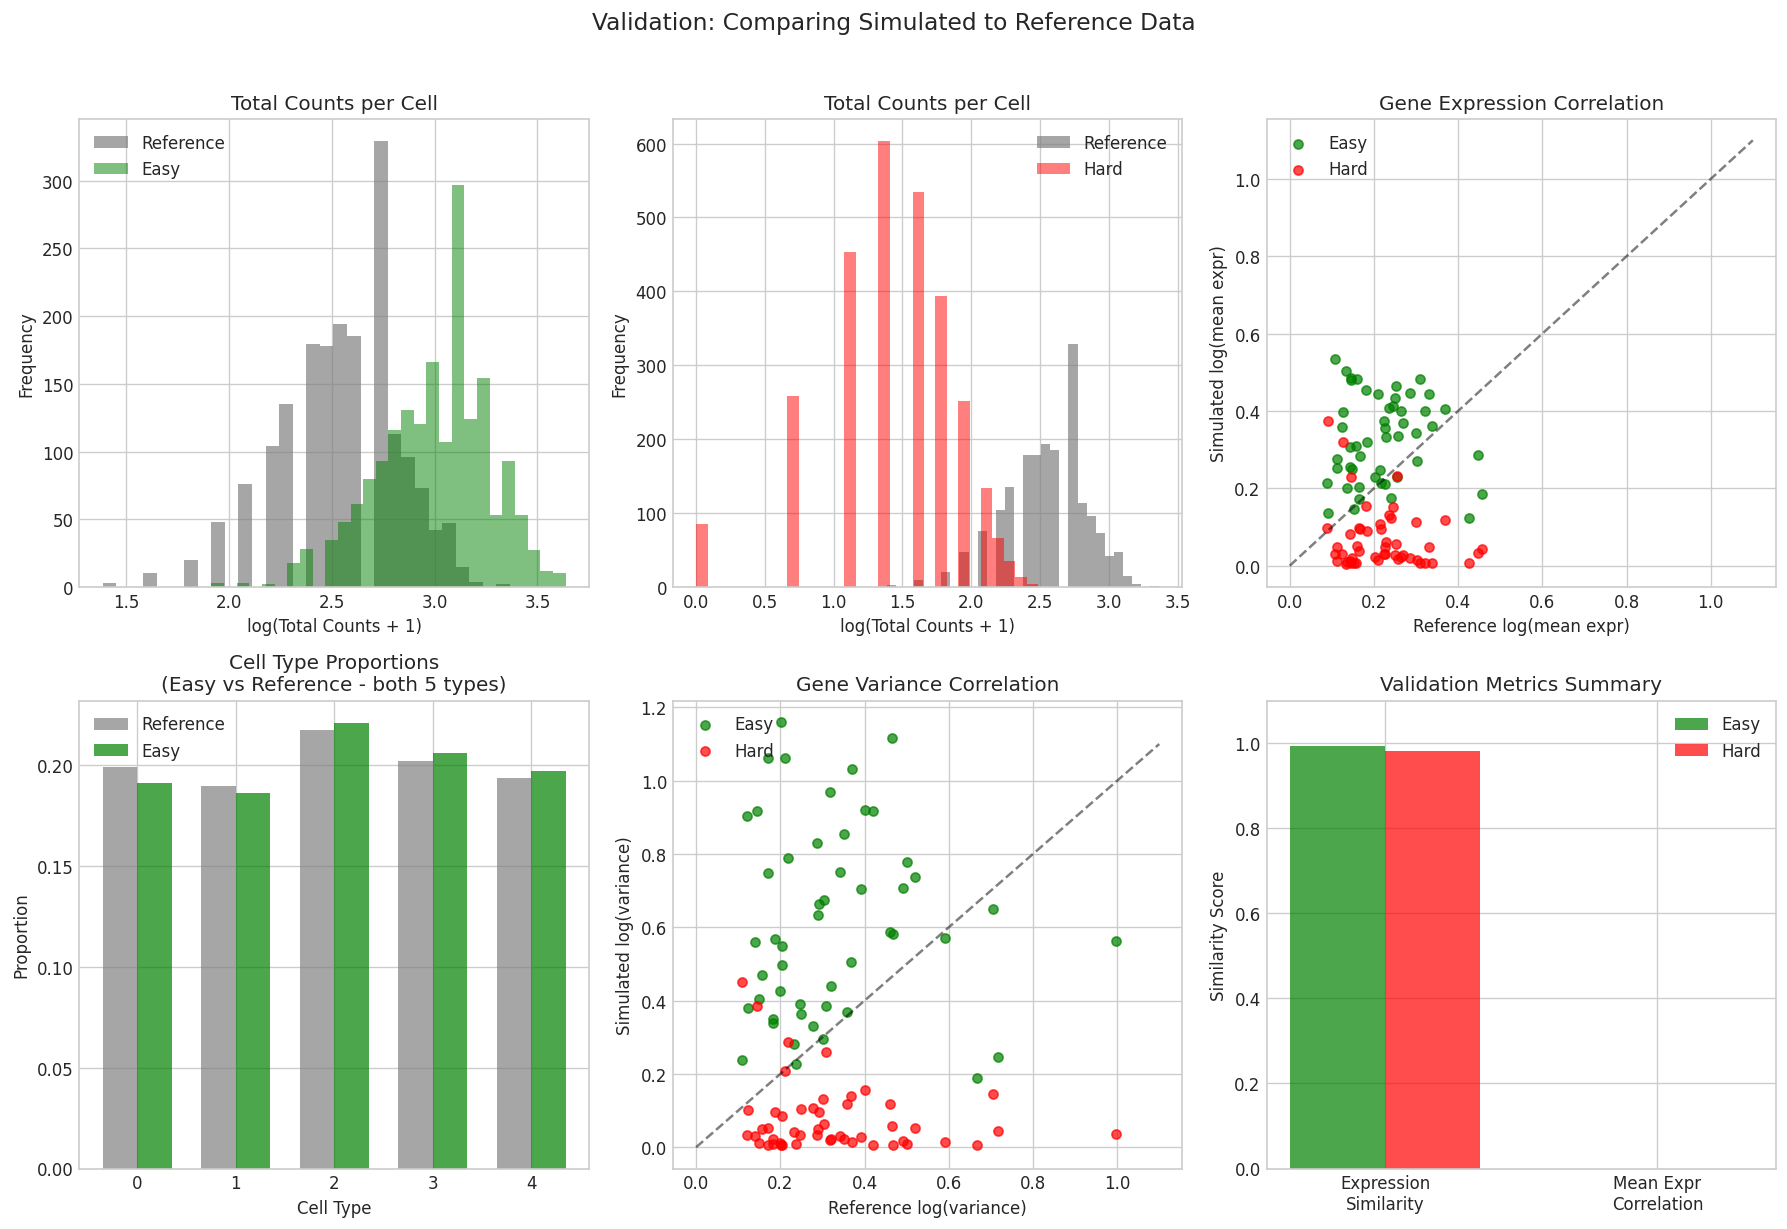

In [16]:
# Detailed comparison visualizations
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Row 1: Expression distributions
ax = axes[0, 0]
ax.hist(np.log1p(counts_ref.sum(axis=1)), bins=30, alpha=0.7, label='Reference', color='gray')
ax.hist(np.log1p(counts_easy.sum(axis=1)), bins=30, alpha=0.5, label='Easy', color='green')
ax.set_xlabel('log(Total Counts + 1)')
ax.set_ylabel('Frequency')
ax.set_title('Total Counts per Cell')
ax.legend()

ax = axes[0, 1]
ax.hist(np.log1p(counts_ref.sum(axis=1)), bins=30, alpha=0.7, label='Reference', color='gray')
ax.hist(np.log1p(counts_hard.sum(axis=1)), bins=30, alpha=0.5, label='Hard', color='red')
ax.set_xlabel('log(Total Counts + 1)')
ax.set_ylabel('Frequency')
ax.set_title('Total Counts per Cell')
ax.legend()

# Gene expression correlation
ax = axes[0, 2]
mean_ref = counts_ref.mean(axis=0)
mean_easy = counts_easy.mean(axis=0)
mean_hard = counts_hard.mean(axis=0)
ax.scatter(np.log1p(mean_ref), np.log1p(mean_easy), alpha=0.7, label='Easy', color='green', s=30)
ax.scatter(np.log1p(mean_ref), np.log1p(mean_hard), alpha=0.7, label='Hard', color='red', s=30)
ax.plot([0, 1.1], [0, 1.1], 'k--', alpha=0.5)
ax.set_xlabel('Reference log(mean expr)')
ax.set_ylabel('Simulated log(mean expr)')
ax.set_title('Gene Expression Correlation')
ax.legend()

# Row 2: Cell type proportions (ONLY compare Easy vs Reference - same # of types)
ax = axes[1, 0]
from collections import Counter
props_ref = np.array([Counter(fov_ref.class_instance).get(i, 0) for i in range(n_cell_types)]) / fov_ref.n_cells
props_easy = np.array([Counter(fov_easy.class_instance).get(i, 0) for i in range(n_cell_types)]) / fov_easy.n_cells

x = np.arange(n_cell_types)
width = 0.35
ax.bar(x - width/2, props_ref, width, label='Reference', color='gray', alpha=0.7)
ax.bar(x + width/2, props_easy, width, label='Easy', color='green', alpha=0.7)
ax.set_xlabel('Cell Type')
ax.set_ylabel('Proportion')
ax.set_title('Cell Type Proportions\n(Easy vs Reference - both 5 types)')
ax.legend()

# Gene variance comparison
ax = axes[1, 1]
var_ref = counts_ref.var(axis=0)
var_easy = counts_easy.var(axis=0)
var_hard = counts_hard.var(axis=0)
ax.scatter(np.log1p(var_ref), np.log1p(var_easy), alpha=0.7, label='Easy', color='green', s=30)
ax.scatter(np.log1p(var_ref), np.log1p(var_hard), alpha=0.7, label='Hard', color='red', s=30)
ax.plot([0, 1.1], [0, 1.1], 'k--', alpha=0.5)
ax.set_xlabel('Reference log(variance)')
ax.set_ylabel('Simulated log(variance)')
ax.set_title('Gene Variance Correlation')
ax.legend()

# Summary metrics
ax = axes[1, 2]
metrics_to_plot = ['expression_similarity', 'mean_expression_correlation']
easy_vals = [metrics_easy.get(m, 0) for m in metrics_to_plot]
hard_vals = [metrics_hard.get(m, 0) for m in metrics_to_plot]

x = np.arange(len(metrics_to_plot))
width = 0.35
ax.bar(x - width/2, easy_vals, width, label='Easy', color='green', alpha=0.7)
ax.bar(x + width/2, hard_vals, width, label='Hard', color='red', alpha=0.7)
ax.set_ylabel('Similarity Score')
ax.set_title('Validation Metrics Summary')
ax.set_xticks(x)
ax.set_xticklabels(['Expression\nSimilarity', 'Mean Expr\nCorrelation'], rotation=0, ha='center')
ax.legend()
ax.set_ylim(0, 1.1)

plt.suptitle('Validation: Comparing Simulated to Reference Data', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [17]:
# Generate multiple FOVs with varying parameters
from tqdm import tqdm

concentrations = [0.5, 0.6, 0.7, 0.8, 0.9, 0.95]
n_replicates = 3

evaluation_results = []

for conc in tqdm(concentrations, desc="Evaluating concentrations"):
    for rep in range(n_replicates):
        # Create tissue with this concentration
        np.random.seed(int(conc * 1000) + rep)
        
        tissue_test = TissueCellTypes()
        tissue_test.generate_types_and_markers(
            n_genes=n_genes,
            n_cell_types=n_cell_types,
            expected_level=12.0,
            concentration=conc,
        )
        
        # Generate FOV using easy generation (simple spatial patterns)
        fov_test = generate_fov_easy(tissue_test, n_cell_types)
        cell_props_test = CellTypesProperties(n_cell_types=n_cell_types)
        cell_props_test.apply(fov_test)
        hybiss_test = HybISS_Setup(tissue_test)
        hybiss_test.observe_dots(fov_test)
        counts_test = get_count_matrix(fov_test, hybiss_test, tissue_test)
        
        # Score difficulty (use count matrix)
        scorer_test = DifficultyScorer(use_classifier=False)  # Skip classifier for speed
        difficulty = scorer_test.score(
            counts_test, 
            fov_test.class_instance,
            positions=fov_test.cell_centroids
        )
        
        # Estimate classifier accuracy
        if counts_test.sum() > 0:
            try:
                acc, _ = estimate_classifier_accuracy(
                    counts_test, fov_test.class_instance, 'rf'
                )
            except:
                acc = 0.0
        else:
            acc = 0.0
        
        evaluation_results.append({
            'concentration': conc,
            'replicate': rep,
            'separability': difficulty.get('separability', 0),
            'classifier_accuracy': acc,
            'n_cells': fov_test.n_cells,
            'n_dots': hybiss_test.make_pandas_df().shape[0],
        })

eval_df = pd.DataFrame(evaluation_results)
print(f"Evaluated {len(eval_df)} simulations")

Evaluating concentrations: 100%|██████████| 6/6 [00:29<00:00,  4.86s/it]

Evaluated 18 simulations


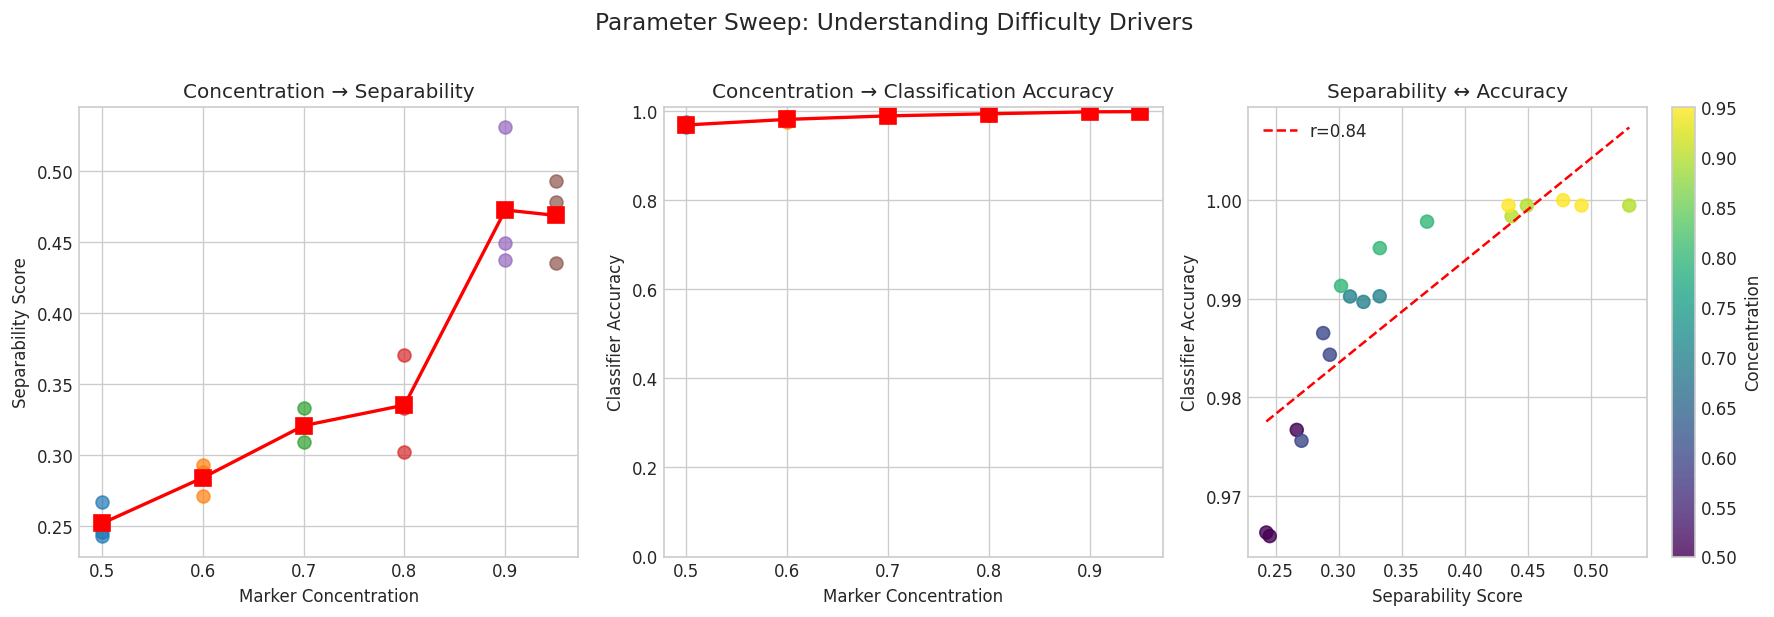

In [19]:
# Visualize the relationship between parameters and difficulty
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Concentration vs Separability
ax = axes[0]
for conc in eval_df['concentration'].unique():
    data = eval_df[eval_df['concentration'] == conc]
    ax.scatter([conc] * len(data), data['separability'], alpha=0.7, s=60)
means = eval_df.groupby('concentration')['separability'].mean()
ax.plot(means.index, means.values, 'r-', linewidth=2, marker='s', markersize=10)
ax.set_xlabel('Marker Concentration')
ax.set_ylabel('Separability Score')
ax.set_title('Concentration → Separability')

# Concentration vs Accuracy
ax = axes[1]
for conc in eval_df['concentration'].unique():
    data = eval_df[eval_df['concentration'] == conc]
    ax.scatter([conc] * len(data), data['classifier_accuracy'], alpha=0.7, s=60)
means = eval_df.groupby('concentration')['classifier_accuracy'].mean()
ax.plot(means.index, means.values, 'r-', linewidth=2, marker='s', markersize=10)
ax.set_xlabel('Marker Concentration')
ax.set_ylabel('Classifier Accuracy')
ax.set_title('Concentration → Classification Accuracy')
ax.set_ylim(0, 1.01)

# Separability vs Accuracy
ax = axes[2]
scatter = ax.scatter(eval_df['separability'], eval_df['classifier_accuracy'],
                     c=eval_df['concentration'], cmap='viridis', s=60, alpha=0.8)
plt.colorbar(scatter, ax=ax, label='Concentration')
ax.set_xlabel('Separability Score')
ax.set_ylabel('Classifier Accuracy')
ax.set_title('Separability ↔ Accuracy')

# Fit regression line
from scipy import stats
slope, intercept, r, p, se = stats.linregress(eval_df['separability'], eval_df['classifier_accuracy'])
x_line = np.linspace(eval_df['separability'].min(), eval_df['separability'].max(), 100)
ax.plot(x_line, slope * x_line + intercept, 'r--', label=f'r={r:.2f}')
ax.legend()

plt.suptitle('Parameter Sweep: Understanding Difficulty Drivers', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [20]:
def create_difficulty_calibrated_dataset(
    n_types=8,
    use_simple_spatial=True
):
    """
    Create a dataset with specific classification difficulty.
    
    Counter-intuitive finding:
    - SIMPLE spatial patterns (random mixing) → HARDER classification
    - COMPLEX spatial patterns (gradients, layers) → EASIER classification
    
    Why? Complex patterns create STRUCTURE that classifiers can exploit.
    Random patterns create maximum confusion with no spatial signal.
    
    For truly hard tasks:
    - Use more cell types (6-10)
    - Lower concentration (0.3-0.4) 
    - Lower expression (2-4)
    - SIMPLE random spatial patterns (not complex!)
    """
    # Start with challenging expression parameters
    concentration = 0.35
    expression_level = 3.0
    
    np.random.seed(42)
    tissue_test = TissueCellTypes()
    tissue_test.generate_types_and_markers(
        n_genes=n_genes,
        n_cell_types=n_types,
        expected_level=expression_level,
        concentration=concentration,
    )
    
    if use_simple_spatial:
        # Simple random patterns = HARDER
        fov_test = generate_fov_easy(tissue_test, n_types)
    else:
        # Complex structured patterns = EASIER
        fov_test = generate_fov_hard(tissue_test, n_types)
    
    cell_props_test = CellTypesProperties(n_cell_types=n_types)
    cell_props_test.apply(fov_test)
    hybiss_test = HybISS_Setup(tissue_test)
    hybiss_test.observe_dots(fov_test)
    counts_test = get_count_matrix(fov_test, hybiss_test, tissue_test)
    
    try:
        acc, std = estimate_classifier_accuracy(counts_test, fov_test.class_instance, 'rf')
    except:
        acc, std = 0.5, 0.0
    
    return {
        'tissue': tissue_test,
        'fov': fov_test,
        'counts': counts_test,
        'accuracy': acc,
        'std': std,
        'n_types': n_types,
        'concentration': concentration,
        'expression_level': expression_level,
    }

print("=" * 70)
print("TESTING SPATIAL PATTERN EFFECTS ON DIFFICULTY")
print("=" * 70)

# Create truly challenging dataset with SIMPLE spatial patterns
print("\n1. Hard case - Simple spatial patterns (random mixing):")
print("   - 8 cell types (more confusion)")
print("   - Concentration 0.35 (highly overlapping markers)")
print("   - Expression level 3.0 (low signal)")
print("   - SIMPLE random spatial patterns")
print()

simple_hard = create_difficulty_calibrated_dataset(
    n_types=8,
    use_simple_spatial=True  # Random patterns = HARDER
)

print(f"   Result: {simple_hard['accuracy']:.1%} ± {simple_hard['std']:.1%} accuracy")
print(f"   ({simple_hard['fov'].n_cells} cells, {simple_hard['n_types']} types)")

# Compare with complex spatial patterns
print("\n2. Moderate case - Complex spatial patterns (gradients, layers):")
print("   - Same expression parameters as above")
print("   - COMPLEX spatial patterns (CompositeRule, GradientRule, LayerRule)")
print()

complex_moderate = create_difficulty_calibrated_dataset(
    n_types=8,
    use_simple_spatial=False  # Structured patterns = EASIER
)

print(f"   Result: {complex_moderate['accuracy']:.1%} ± {complex_moderate['std']:.1%} accuracy")

print("\n" + "=" * 70)
print("KEY INSIGHT:")
print("=" * 70)
print("Complex spatial patterns (gradients, layers) actually make classification")
print("EASIER because they create spatial structure that classifiers can learn!")
print()
print("For maximum difficulty: Use SIMPLE random patterns, not complex ones.")
print("=" * 70)

TESTING SPATIAL PATTERN EFFECTS ON DIFFICULTY

1. Hard case - Simple spatial patterns (random mixing):
   - 8 cell types (more confusion)
   - Concentration 0.35 (highly overlapping markers)
   - Expression level 3.0 (low signal)
   - SIMPLE random spatial patterns

   Result: 50.2% ± 2.9% accuracy
   (1843 cells, 8 types)

2. Moderate case - Complex spatial patterns (gradients, layers):
   - Same expression parameters as above
   - COMPLEX spatial patterns (CompositeRule, GradientRule, LayerRule)

   Result: 68.2% ± 2.4% accuracy

KEY INSIGHT:
Complex spatial patterns (gradients, layers) actually make classification
EASIER because they create spatial structure that classifiers can learn!

For maximum difficulty: Use SIMPLE random patterns, not complex ones.


---
## Summary

This notebook covered PointillSim's validation and difficulty assessment tools:

| Tool | Purpose |
|------|--------|
| `DifficultyScorer` | Quantify classification difficulty |
| `ValidationMetrics` | Compare simulated vs reference data |
| Classifier accuracy | Practical difficulty estimation |
| Parameter sweeps | Understanding difficulty drivers |

### Key Takeaways

1. **Separability** correlates strongly with classifier accuracy
2. **Marker concentration** is a primary driver of difficulty
3. **Spatial patterns matter - but not as expected!**
   - Random/mixed spatial patterns are HARDER to classify
   - Structured patterns (gradients, layers) provide information that aids classification
4. **Combining strategies** creates the hardest benchmarks:
   - More cell types (8+ instead of 5)
   - Lower concentration (0.3-0.4 instead of 0.8+)
   - Lower expression levels (2-4 instead of 12+)
   - **Random spatial mixing** (NOT complex rules)
5. **Validation metrics** help ensure simulations are realistic

### Creating Truly Difficult Tasks

The key insight: **Structure helps classification, randomness hinders it!**

To achieve low accuracy (<60%):
- Use **simple random assignment** (`RandomCellTypeRule`, `MixOfNCellTypesRule`)
- Increase number of cell types (8-10 instead of 5)
- Decrease marker concentration (<0.4) and expression level (<4)
- Avoid structured spatial patterns (gradients, layers) which make classification easier

Finding: Complex spatial rules like `GradientRule` and `LayerRule` 
create spatial structure that classifiers can exploit. For maximum difficulty, use 
random mixing with overlapping expression profiles.